<a href="https://colab.research.google.com/github/drskprabhakar/AI-ML-DL-colab-notebooks-coding-models/blob/main/PreopAKrawdata.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
df=pd.read_excel('/content/drive/MyDrive/AK and AR 1wk, 6wk and 3 months.xlsx')

In [ ]:
df.head()

,PreopR1,PreopR2,PreopA1,PreopVA,POD 1wkVA,Sph1wk,Cyl1wk,Axis1wk,POD 6wkVA,Sph6wk,Cyl6wk,Axis6wk,POD 3mthVA,Sph3mth,Cyl3mth,Axis3mth
0,46.50,47.25,155,6\24,6\12,0.25,-1.50,115.0,6\12,0.25,-1.25,100.0,6\9,0.5,-1.0,65.0
1,46.75,48.00,80,HM,6\18,0.75,-2.25,80.0,6\18,0.75,-2.00,90.0,6\12,0.5,-2.0,80.0
2,44.00,44.25,20,6\60,6\24,NO CENTER,NaN,NaN,6\24,-1.5,-1.00,140.0,NaN,NaN,NaN,NaN
3,45.25,45.75,120,CF@1M,6\18,-0.75,-1.00,160.0,6\18,-0.5,-0.75,140.0,6\9,-0.5,-0.5,150.0
4,45.50,47.00,80,6\36,6\12,0.25,2.00,75.0,6\12,0.25,2.25,85.0,NaN,NaN,NaN,NaN


In [ ]:
sheets= pd.ExcelFile('/content/drive/MyDrive/AK and AR 1wk, 6wk and 3 months.xlsx')
sheets.sheet_names

['data 1wk, 6wk and 3 months', 'raw data']

In [ ]:
rawdata = sheets.parse('raw data')

In [ ]:
rawdata.head()

,Age,Gender,PreopR1,PreopR2,PreopA1,PreopVA,POD 1wkVA,Sph1wk,Cyl1wk,Axis1wk,POD 6wkVA,Sph6wk,Cyl6wk,Axis6wk,POD 3mthVA,Sph3mth,Cyl3mth,Axis3mth
0,54,F,46.50,47.25,155,6\24,6\12,0.25,-1.50,115.0,6\12,0.25,-1.25,100.0,6\9,0.5,-1.0,65.0
1,63,F,46.75,48.00,80,HM,6\18,0.75,-2.25,80.0,6\18,0.75,-2.00,90.0,6\12,0.5,-2.0,80.0
2,78,F,44.00,44.25,20,6\60,6\24,NO CENTER,NaN,NaN,6\24,-1.5,-1.00,140.0,NaN,NaN,NaN,NaN
3,71,F,45.25,45.75,120,CF@1M,6\18,-0.75,-1.00,160.0,6\18,-0.5,-0.75,140.0,6\9,-0.5,-0.5,150.0
4,89,M,45.50,47.00,80,6\36,6\12,0.25,2.00,75.0,6\12,0.25,2.25,85.0,NaN,NaN,NaN,NaN


In [ ]:
rawdata.columns

Index(['Age', 'Gender ', 'PreopR1', 'PreopR2', 'PreopA1', 'PreopVA',
       'POD 1wkVA', 'Sph1wk', 'Cyl1wk', 'Axis1wk', 'POD 6wkVA', 'Sph6wk ',
       'Cyl6wk', 'Axis6wk', 'POD 3mthVA', 'Sph3mth', 'Cyl3mth', 'Axis3mth'],
      dtype='object')

In [ ]:
rawdata.shape

(174, 18)

In [ ]:
# Function to remove outliers using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return df_filtered

# Columns to remove outliers from
columns_to_filter = ['PreopR1', 'PreopR2', 'PreopA1']

# Apply outlier removal to each specified column
rawdata_filtered = rawdata.copy()
for col in columns_to_filter:
    rawdata_filtered = remove_outliers_iqr(rawdata_filtered, col)

display(rawdata_filtered.head())
display(rawdata_filtered.shape)

,Age,Gender,PreopR1,PreopR2,PreopA1,PreopVA,POD 1wkVA,Sph1wk,Cyl1wk,Axis1wk,POD 6wkVA,Sph6wk,Cyl6wk,Axis6wk,POD 3mthVA,Sph3mth,Cyl3mth,Axis3mth
0,54,F,46.50,47.25,155,6\24,6\12,0.25,-1.50,115.0,6\12,0.25,-1.25,100.0,6\9,0.5,-1.0,65.0
1,63,F,46.75,48.00,80,HM,6\18,0.75,-2.25,80.0,6\18,0.75,-2.00,90.0,6\12,0.5,-2.0,80.0
2,78,F,44.00,44.25,20,6\60,6\24,NO CENTER,NaN,NaN,6\24,-1.5,-1.00,140.0,NaN,NaN,NaN,NaN
3,71,F,45.25,45.75,120,CF@1M,6\18,-0.75,-1.00,160.0,6\18,-0.5,-0.75,140.0,6\9,-0.5,-0.5,150.0
4,89,M,45.50,47.00,80,6\36,6\12,0.25,2.00,75.0,6\12,0.25,2.25,85.0,NaN,NaN,NaN,NaN


(172, 18)

<Axes: >

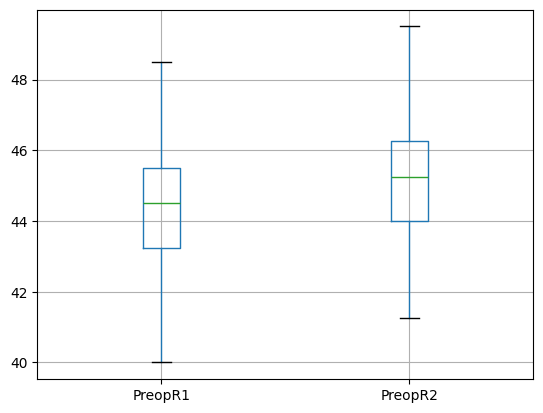

In [ ]:
rawdata_filtered.boxplot(column=['PreopR1', 'PreopR2'])




In [ ]:
rawdata_filtered.columns

Index(['Age', 'Gender ', 'PreopR1', 'PreopR2', 'PreopA1', 'PreopVA',
       'POD 1wkVA', 'Sph1wk', 'Cyl1wk', 'Axis1wk', 'POD 6wkVA', 'Sph6wk ',
       'Cyl6wk', 'Axis6wk', 'POD 3mthVA', 'Sph3mth', 'Cyl3mth', 'Axis3mth'],
      dtype='object')

In [ ]:
import numpy as np
import pandas as pd

def convert_to_logmar(va_string):
    """Converts a visual acuity string (e.g., '6/12', '6\\12', 'HM', 'CF@1M') to logMAR."""
    if isinstance(va_string, str):
        va_string = va_string.strip().upper().replace('\\', '/')

        if '/' in va_string:
            try:
                numerator, denominator = va_string.split('/')
                return np.log10(int(denominator) / int(numerator))
            except ValueError:
                return np.nan

        elif 'NLP' in va_string:
            return 3.0
        elif 'LP' in va_string:
            return 2.3
        elif 'HM' in va_string:
            return 2.9
        elif 'CF' in va_string:
            return 2.6
        elif 'NO CENTER' in va_string:
            return np.nan
        else:
            return np.nan

    elif pd.isna(va_string):
        return np.nan
    else:
        return np.nan


# Apply function
rawdata_filtered['POD 1wkVA LogMAR'] = rawdata_filtered['POD 1wkVA'].apply(convert_to_logmar)
display(rawdata_filtered[['POD 1wkVA', 'POD 1wkVA LogMAR']].head())


,POD 1wkVA,POD 1wkVA LogMAR
0,6\12,0.301030
1,6\18,0.477121
2,6\24,0.602060
3,6\18,0.477121
4,6\12,0.301030


In [ ]:
rawdata_filtered

,Age,Gender,PreopR1,PreopR2,PreopA1,PreopVA,POD 1wkVA,Sph1wk,Cyl1wk,Axis1wk,POD 6wkVA,Sph6wk,Cyl6wk,Axis6wk,POD 3mthVA,Sph3mth,Cyl3mth,Axis3mth,POD 1wkVA LogMAR
0,54,F,46.50,47.25,155,6\24,6\12,0.25,-1.50,115.0,6\12,0.25,-1.25,100.0,6\9,0.50,-1.00,65.0,0.301030
1,63,F,46.75,48.00,80,HM,6\18,0.75,-2.25,80.0,6\18,0.75,-2.00,90.0,6\12,0.50,-2.00,80.0,0.477121
2,78,F,44.00,44.25,20,6\60,6\24,NO CENTER,NaN,NaN,6\24,-1.5,-1.00,140.0,NaN,NaN,NaN,NaN,0.602060
3,71,F,45.25,45.75,120,CF@1M,6\18,-0.75,-1.00,160.0,6\18,-0.5,-0.75,140.0,6\9,-0.50,-0.50,150.0,0.477121
4,89,M,45.50,47.00,80,6\36,6\12,0.25,2.00,75.0,6\12,0.25,2.25,85.0,NaN,NaN,NaN,NaN,0.301030
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
169,54,M,45.00,46.25,165,6\36,6\18,-2.75,-3.00,75.0,6\12,-2,-2.50,110.0,6\12,-1.75,-2.25,90.0,0.477121
170,57,M,41.00,42.50,85,CF @ 1M,6\18,NO CENTER,NaN,NaN,6\9,-2,-1.25,90.0,6\9,-1.00,-1.25,65.0,0.477121
171,72,M,44.75,45.75,75,6\18,6\36,NO CENTER,NaN,NaN,6\18,-2.5,-4.25,10.0,NaN,NaN,NaN,NaN,0.778151
172,74,M,44.75,45.25,170,6\36,6\18,NO CENTER,NaN,NaN,6\12,-1,3.25,150.0,NaN,NaN,NaN,NaN,0.477121


In [ ]:
# Reuse the same function defined earlier
import numpy as np
import pandas as pd

def convert_to_logmar(va_string):
    """Converts a visual acuity string (e.g., '6/12', '6\\12', 'HM', 'CF@1M') to logMAR."""
    if isinstance(va_string, str):
        va_string = va_string.strip().upper().replace('\\', '/')

        if '/' in va_string:
            try:
                numerator, denominator = va_string.split('/')
                return np.log10(int(denominator) / int(numerator))
            except ValueError:
                return np.nan

        elif 'NLP' in va_string:
            return 3.0
        elif 'LP' in va_string:
            return 2.3
        elif 'HM' in va_string:
            return 2.9
        elif 'CF' in va_string:
            return 2.6
        elif 'NO CENTER' in va_string:
            return np.nan
        else:
            return np.nan

    elif pd.isna(va_string):
        return np.nan
    else:
        return np.nan


# ✅ Apply to the 6-week VA column
rawdata_filtered['POD 6wkVA LogMAR'] = rawdata_filtered['POD 6wkVA'].apply(convert_to_logmar)

# ✅ Display a preview
display(rawdata_filtered[['POD 6wkVA', 'POD 6wkVA LogMAR']].head())


,POD 6wkVA,POD 6wkVA LogMAR
0,6\12,0.301030
1,6\18,0.477121
2,6\24,0.602060
3,6\18,0.477121
4,6\12,0.301030


In [ ]:
import numpy as np
import pandas as pd

def convert_to_logmar(va_string):
    """Converts a visual acuity string (e.g., '6/12', '6\\12', 'HM', 'CF@1M') to logMAR."""
    if isinstance(va_string, str):
        va_string = va_string.strip().upper().replace('\\', '/')  # handle both \ and /

        if '/' in va_string:
            try:
                numerator, denominator = va_string.split('/')
                return np.log10(int(denominator) / int(numerator))
            except ValueError:
                return np.nan

        elif 'NLP' in va_string:
            return 3.0
        elif 'LP' in va_string:
            return 2.3
        elif 'HM' in va_string:
            return 2.9
        elif 'CF' in va_string:
            return 2.6
        elif 'NO CENTER' in va_string:
            return np.nan
        else:
            return np.nan

    elif pd.isna(va_string):
        return np.nan
    else:
        return np.nan


# ✅ Apply to the 3-month VA column
rawdata_filtered['POD 3mthVA LogMAR'] = rawdata_filtered['POD 3mthVA'].apply(convert_to_logmar)

# ✅ Display a preview
display(rawdata_filtered[['POD 3mthVA', 'POD 3mthVA LogMAR']].head())


,POD 3mthVA,POD 3mthVA LogMAR
0,6\9,0.176091
1,6\12,0.301030
2,NaN,NaN
3,6\9,0.176091
4,NaN,NaN


In [ ]:
import numpy as np
import pandas as pd

def convert_to_logmar(va_string):
    """Converts a visual acuity string (e.g., '6/12', '6\\12', 'HM', 'CF@1M') to logMAR."""
    if isinstance(va_string, str):
        va_string = va_string.strip().upper().replace('\\', '/')  # Handle both \ and /

        if '/' in va_string:
            try:
                numerator, denominator = va_string.split('/')
                return np.log10(int(denominator) / int(numerator))
            except ValueError:
                return np.nan

        elif 'NLP' in va_string:
            return 3.0
        elif 'LP' in va_string:
            return 2.3
        elif 'HM' in va_string:
            return 2.9
        elif 'CF' in va_string:
            return 2.6
        elif 'NO CENTER' in va_string:
            return np.nan
        else:
            return np.nan

    elif pd.isna(va_string):
        return np.nan
    else:
        return np.nan


# ✅ Apply to the Preop VA column
rawdata_filtered['PreopVA LogMAR'] = rawdata_filtered['PreopVA'].apply(convert_to_logmar)

# ✅ Display a preview
display(rawdata_filtered[['PreopVA', 'PreopVA LogMAR']].head())


,PreopVA,PreopVA LogMAR
0,6\24,0.602060
1,HM,2.900000
2,6\60,1.000000
3,CF@1M,2.600000
4,6\36,0.778151


In [ ]:
rawdata_filtered.to_excel('filtered_data.xlsx', index=False)

In [ ]:
rawdata_filtered.shape

(172, 22)

In [ ]:
rawdata_filtered.columns

Index(['Age', 'Gender ', 'PreopR1', 'PreopR2', 'PreopA1', 'PreopVA',
       'POD 1wkVA', 'Sph1wk', 'Cyl1wk', 'Axis1wk', 'POD 6wkVA', 'Sph6wk ',
       'Cyl6wk', 'Axis6wk', 'POD 3mthVA', 'Sph3mth', 'Cyl3mth', 'Axis3mth',
       'POD 1wkVA LogMAR', 'POD 6wkVA LogMAR', 'POD 3mthVA LogMAR',
       'PreopVA LogMAR'],
      dtype='object')

In [ ]:
# Remove the original VA columns (keep only LogMAR versions)
rawdata_filtered = rawdata_filtered.drop(
    columns=['PreopVA', 'POD 1wkVA', 'POD 6wkVA', 'POD 3mthVA']
)

# Check that the columns were removed
rawdata_filtered.columns


Index(['Age', 'Gender ', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk ', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth', 'POD 1wkVA LogMAR', 'POD 6wkVA LogMAR', 'POD 3mthVA LogMAR',
       'PreopVA LogMAR'],
      dtype='object')

In [ ]:
rawdata_filtered.head()

,Age,Gender,PreopR1,PreopR2,PreopA1,Sph1wk,Cyl1wk,Axis1wk,Sph6wk,Cyl6wk,Axis6wk,Sph3mth,Cyl3mth,Axis3mth,POD 1wkVA LogMAR,POD 6wkVA LogMAR,POD 3mthVA LogMAR,PreopVA LogMAR
0,54,F,46.50,47.25,155,0.25,-1.50,115.0,0.25,-1.25,100.0,0.5,-1.0,65.0,0.301030,0.301030,0.176091,0.602060
1,63,F,46.75,48.00,80,0.75,-2.25,80.0,0.75,-2.00,90.0,0.5,-2.0,80.0,0.477121,0.477121,0.301030,2.900000
2,78,F,44.00,44.25,20,NO CENTER,NaN,NaN,-1.5,-1.00,140.0,NaN,NaN,NaN,0.602060,0.602060,NaN,1.000000
3,71,F,45.25,45.75,120,-0.75,-1.00,160.0,-0.5,-0.75,140.0,-0.5,-0.5,150.0,0.477121,0.477121,0.176091,2.600000
4,89,M,45.50,47.00,80,0.25,2.00,75.0,0.25,2.25,85.0,NaN,NaN,NaN,0.301030,0.301030,NaN,0.778151


In [ ]:
rawdata_filtered.shape

(172, 18)

In [ ]:
rawdata_filtered['Age'].describe()

,Age
count,172.000000
mean,63.941860
std,9.826393
min,38.000000
25%,56.750000
50%,65.000000
75%,71.000000
max,93.000000


In [ ]:
rawdata_filtered.groupby('Gender ')['Age'].describe()


,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,107.0,64.093458,9.737627,39.0,57.0,65.0,71.0,93.0
M,65.0,63.692308,10.041979,38.0,56.0,65.0,69.0,89.0


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Select relevant columns
cols = ['PreopR1', 'PreopR2', 'PreopA1']
df = rawdata_filtered[cols]

# Function to calculate extended statistics
def extended_stats(series):
    n = series.count()  # non-NA count
    mean = series.mean()
    std = series.std(ddof=1)
    sem = std / np.sqrt(n)  # standard error
    skewness = series.skew()
    kurt = series.kurtosis()
    # 95% confidence interval
    ci_low, ci_high = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)

    return pd.Series({
        'count': n,
        'mean': mean,
        'std': std,
        'sem': sem,
        'skewness': skewness,
        'kurtosis': kurt,
        '95% CI lower': ci_low,
        '95% CI upper': ci_high
    })

# Apply function to each column
extended_describe = df.apply(extended_stats)
print(extended_describe)


                 PreopR1     PreopR2     PreopA1
count         172.000000  172.000000  172.000000
mean           44.409884   45.207849  100.029070
std             1.603137    1.644158   49.819842
sem             0.122238    0.125366    3.798727
skewness       -0.255752    0.067869    0.082534
kurtosis       -0.118221   -0.249358   -0.894480
95% CI lower   44.168594   44.960385   92.530633
95% CI upper   44.651174   45.455313  107.527507


In [ ]:
# Create a new column 'PreopCylinder'
rawdata_filtered['PreopCylinder'] = rawdata_filtered['PreopR2'] - rawdata_filtered['PreopR1']

# View the first few rows to check
rawdata_filtered[['PreopR1', 'PreopR2', 'PreopCylinder']].head()


,PreopR1,PreopR2,PreopCylinder
0,46.50,47.25,0.75
1,46.75,48.00,1.25
2,44.00,44.25,0.25
3,45.25,45.75,0.50
4,45.50,47.00,1.50


In [ ]:
# Calculate Steep Axis
rawdata_filtered['PreopSteepAxis'] = (rawdata_filtered['PreopA1'] + 90) % 180

# View first few rows
rawdata_filtered[['PreopA1', 'PreopSteepAxis']].head()


,PreopA1,PreopSteepAxis
0,155,65
1,80,170
2,20,110
3,120,30
4,80,170


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Select the columns of interest
cols = ['PreopCylinder', 'PreopSteepAxis']
df = rawdata_filtered[cols]

# Function to calculate extended statistics
def extended_stats(series):
    n = series.count()  # non-NA count
    mean = series.mean()
    std = series.std(ddof=1)
    sem = std / np.sqrt(n)  # standard error
    skewness = series.skew()
    kurt = series.kurtosis()
    # 95% confidence interval using t-distribution
    ci_low, ci_high = stats.t.interval(0.95, df=n-1, loc=mean, scale=sem)

    return pd.Series({
        'count': n,
        'mean': mean,
        'std': std,
        'sem': sem,
        'skewness': skewness,
        'kurtosis': kurt,
        '95% CI lower': ci_low,
        '95% CI upper': ci_high
    })

# Apply function to each column
extended_describe = df.apply(extended_stats)
print(extended_describe)


              PreopCylinder  PreopSteepAxis
count            172.000000      172.000000
mean               0.797965      101.075581
std                0.562819       57.324664
sem                0.042915        4.370965
skewness           1.189028       -0.224020
kurtosis           2.074089       -1.241594
95% CI lower       0.713255       92.447586
95% CI upper       0.882676      109.703577


In [ ]:
import numpy as np

# Convert axis to radians
axis_rad = np.deg2rad(rawdata_filtered['PreopSteepAxis'] * 2)  # multiply by 2 for vector analysis

# Cylinder (magnitude)
cyl = rawdata_filtered['PreopCylinder']

# Compute vector components
J0 = -cyl / 2 * np.cos(axis_rad)
J45 = -cyl / 2 * np.sin(axis_rad)

# Compute centroid
J0_centroid = J0.mean()
J45_centroid = J45.mean()

# Convert centroid back to magnitude and axis
C_centroid = 2 * np.sqrt(J0_centroid**2 + J45_centroid**2)
axis_centroid = 0.5 * np.rad2deg(np.arctan2(J45_centroid, J0_centroid))

# Adjust axis to 0–180°
if axis_centroid < 0:
    axis_centroid += 180

print(f"Centroid Cylinder: {C_centroid:.2f} D")
print(f"Centroid Axis: {axis_centroid:.1f}°")


Centroid Cylinder: 0.16 D
Centroid Axis: 83.0°


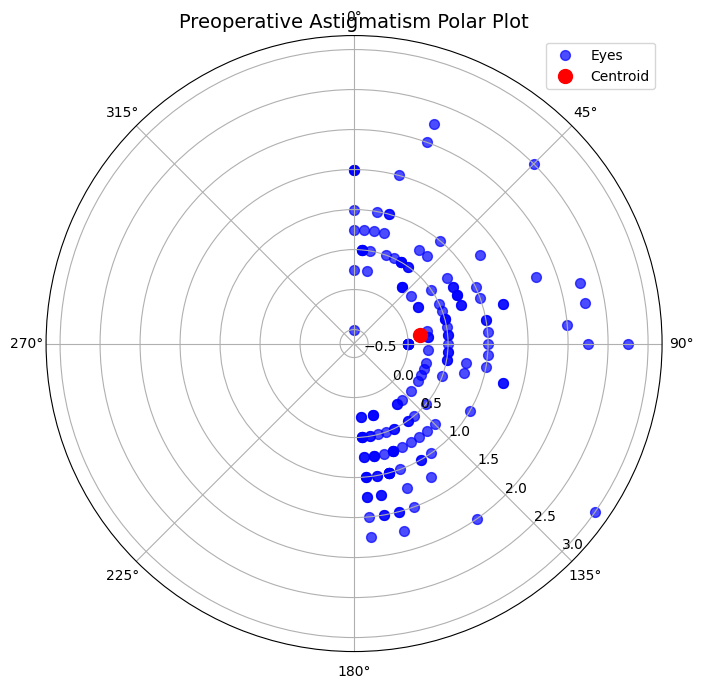

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data
cyl = rawdata_filtered['PreopCylinder']
axis = rawdata_filtered['PreopSteepAxis']

# Convert axis to radians for polar plot
theta = np.deg2rad(axis)

# Create polar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Plot points: cylinder magnitude as radius, axis as angle
# You can multiply by -1 if you want to invert direction for astigmatism conventions
ax.scatter(theta, cyl, c='blue', alpha=0.7, s=50, label='Eyes')

# Optional: plot centroid
J0 = -cyl / 2 * np.cos(2*theta)
J45 = -cyl / 2 * np.sin(2*theta)
J0_centroid = J0.mean()
J45_centroid = J45.mean()
C_centroid = 2 * np.sqrt(J0_centroid**2 + J45_centroid**2)
axis_centroid = 0.5 * np.rad2deg(np.arctan2(J45_centroid, J0_centroid))
if axis_centroid < 0:
    axis_centroid += 180
ax.scatter(np.deg2rad(axis_centroid), C_centroid, c='red', s=100, label='Centroid')

# Formatting
ax.set_theta_zero_location('N')   # 0° at top
ax.set_theta_direction(-1)        # clockwise
ax.set_rlabel_position(135)       # move radial labels
ax.set_title('Preoperative Astigmatism Polar Plot', fontsize=14)
ax.legend(loc='upper right')

plt.show()


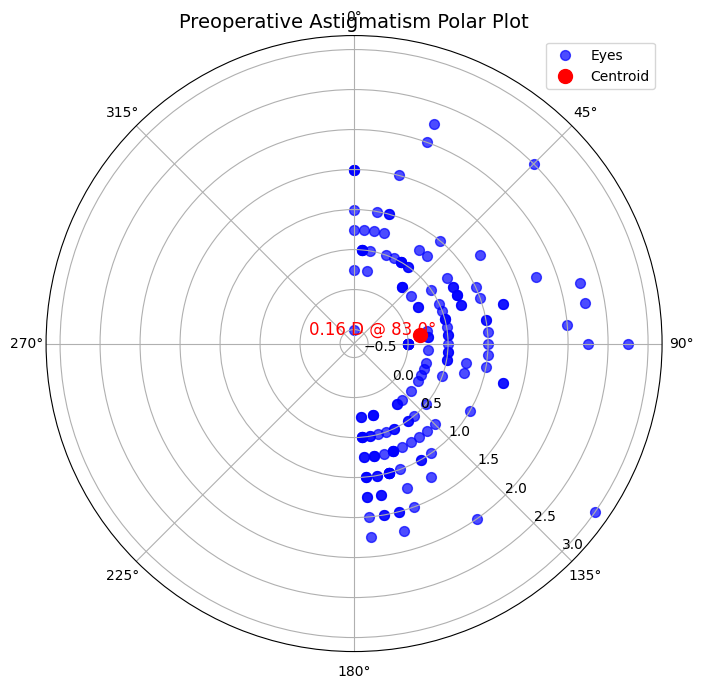

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract data
cyl = rawdata_filtered['PreopCylinder']
axis = rawdata_filtered['PreopSteepAxis']

# Convert axis to radians for polar plot
theta = np.deg2rad(axis)

# Create polar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

# Plot points: cylinder magnitude as radius, axis as angle
ax.scatter(theta, cyl, c='blue', alpha=0.7, s=50, label='Eyes')

# --- Calculate centroid using vector components ---
J0 = -cyl / 2 * np.cos(2*theta)
J45 = -cyl / 2 * np.sin(2*theta)
J0_centroid = J0.mean()
J45_centroid = J45.mean()
C_centroid = 2 * np.sqrt(J0_centroid**2 + J45_centroid**2)
axis_centroid = 0.5 * np.rad2deg(np.arctan2(J45_centroid, J0_centroid))
if axis_centroid < 0:
    axis_centroid += 180

# --- Plot centroid ---
ax.scatter(np.deg2rad(axis_centroid), C_centroid, c='red', s=100, label='Centroid')

# --- Annotate centroid with values ---
ax.text(
    np.deg2rad(axis_centroid),
    C_centroid + 0.2,  # slightly offset for visibility
    f"{C_centroid:.2f} D @ {axis_centroid:.1f}°",
    color='red',
    fontsize=12,
    ha='right'
)

# Formatting
ax.set_theta_zero_location('N')   # 0° at top
ax.set_theta_direction(-1)        # clockwise
ax.set_rlabel_position(135)       # move radial labels
ax.set_title('Preoperative Astigmatism Polar Plot', fontsize=14)
ax.legend(loc='upper right')

plt.show()


In [ ]:
import numpy as np
import pandas as pd

# Example: your dataframe
# rawdata_filtered['PreopSteepAxis'] should contain values from 0°–180°
axis = rawdata_filtered['PreopSteepAxis']

def classify_astigmatism(axis):
    """
    Classify astigmatism based on the steep meridian axis (in degrees)
    """
    if (0 <= axis <= 30) or (150 < axis <= 180):
        return "WTR"   # With-the-rule: steep meridian near 90° (vertical)
    elif (60 < axis <= 120):
        return "ATR"   # Against-the-rule: steep meridian near 180° (horizontal)
    else:
        return "Oblique"

# Apply classification to dataset
rawdata_filtered['Preop_AstigType'] = rawdata_filtered['PreopSteepAxis'].apply(classify_astigmatism)

# Check summary
print(rawdata_filtered['Preop_AstigType'].value_counts())


Preop_AstigType
WTR        80
ATR        57
Oblique    35
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd

def classify_astigmatism(axis):
    """
    Classify astigmatism based on steep meridian axis (degrees)
    """
    if pd.isna(axis):
        return np.nan
    if (0 <= axis <= 30) or (150 < axis <= 180):
        return "ATR"      # Against-the-rule: steep meridian horizontal
    elif (60 <= axis <= 120):
        return "WTR"      # With-the-rule: steep meridian vertical
    else:
        return "Oblique"

# --- Preoperative classification ---
# rawdata_filtered['Preop_AstigType'] = rawdata_filtered['PreopSteepAxis'].apply(classify_astigmatism)

# --- Postoperative (1 week) classification with sign correction ---
# If cylinder is negative, convert to steep axis = (axis + 90) % 180
def get_steep_axis(cyl, axis):
    if pd.isna(cyl) or pd.isna(axis):
        return np.nan
    if cyl < 0:   # minus-cylinder notation
        return (axis + 90) % 180
    else:         # plus-cylinder notation
        return axis

rawdata_filtered['Postop1wk_SteepAxis'] = rawdata_filtered.apply(
    lambda x: get_steep_axis(x['Cyl1wk'], x['Axis1wk']), axis=1
)

# Classify based on corrected steep axis
rawdata_filtered['Postop1wk_AstigType'] = rawdata_filtered['Postop1wk_SteepAxis'].apply(classify_astigmatism)

# --- Display summary ---
# print("Preoperative astigmatism classification:")
# print(rawdata_filtered['Preop_AstigType'].value_counts(dropna=False))

print("\nPostoperative (1 week) astigmatism classification:")
print(rawdata_filtered['Postop1wk_AstigType'].value_counts(dropna=False))



Postoperative (1 week) astigmatism classification:
Postop1wk_AstigType
ATR        79
NaN        41
WTR        30
Oblique    22
Name: count, dtype: int64


In [ ]:
rawdata_filtered.columns

Index(['Age', 'Gender ', 'PreopR1', 'PreopR2', 'PreopA1', 'Sph1wk', 'Cyl1wk',
       'Axis1wk', 'Sph6wk ', 'Cyl6wk', 'Axis6wk', 'Sph3mth', 'Cyl3mth',
       'Axis3mth', 'POD 1wkVA LogMAR', 'POD 6wkVA LogMAR', 'POD 3mthVA LogMAR',
       'PreopVA LogMAR', 'PreopCylinder', 'PreopSteepAxis', 'Preop_AstigType'],
      dtype='object')

In [ ]:
import numpy as np
import pandas as pd

# --- Conversion to consistent minus-cylinder format ---
def normalize_to_minus_cylinder(sph, cyl, axis):
    """
    Convert plus-cylinder notation to minus-cylinder format if needed.
    Returns (sphere, cylinder, axis) all in minus-cylinder format.
    """
    if pd.isna(sph) or pd.isna(cyl) or pd.isna(axis):
        return pd.Series([np.nan, np.nan, np.nan])
    if cyl > 0:  # plus-cylinder format
        sph = sph + cyl
        cyl = -cyl
        axis = (axis + 90) % 180
    return pd.Series([sph, cyl, axis])

rawdata_filtered[['Sph1wk_minus', 'Cyl1wk_minus', 'Axis1wk_minus']] = (
    rawdata_filtered
    .apply(lambda x: normalize_to_minus_cylinder(
        x['Sph1wk'], x['Cyl1wk'], x['Axis1wk']), axis=1)
)

# --- Spherical Equivalent ---
rawdata_filtered['SE1wk'] = rawdata_filtered['Sph1wk_minus'] + (rawdata_filtered['Cyl1wk_minus'] / 2)

# --- Determine steep meridian for classification ---
def get_steep_axis(cyl, axis):
    if pd.isna(cyl) or pd.isna(axis):
        return np.nan
    if cyl < 0:  # minus-cylinder notation
        return (axis + 90) % 180
    else:
        return axis

rawdata_filtered['SteepAxis1wk'] = rawdata_filtered.apply(
    lambda x: get_steep_axis(x['Cyl1wk_minus'], x['Axis1wk_minus']), axis=1
)

# --- Classify astigmatism ---
def classify_astigmatism(axis):
    if pd.isna(axis):
        return np.nan
    if (0 <= axis <= 30) or (150 < axis <= 180):
        return "ATR"
    elif (60 <= axis <= 120):
        return "WTR"
    else:
        return "Oblique"

rawdata_filtered['Postop1wk_AstigType'] = rawdata_filtered['SteepAxis1wk'].apply(classify_astigmatism)

# --- Summary output ---
print(rawdata_filtered[['Sph1wk_minus', 'Cyl1wk_minus', 'Axis1wk_minus','SteepAxis1wk', 'Postop1wk_AstigType', 'SE1wk']].head())


   Sph1wk_minus  Cyl1wk_minus  Axis1wk_minus  SteepAxis1wk  \
0          0.25         -1.50          115.0          25.0   
1          0.75         -2.25           80.0         170.0   
2           NaN           NaN            NaN           NaN   
3         -0.75         -1.00          160.0          70.0   
4          2.25         -2.00          165.0          75.0   

  Postop1wk_AstigType  SE1wk  
0                 ATR -0.500  
1                 ATR -0.375  
2                 NaN    NaN  
3                 WTR -1.250  
4                 WTR  1.250  


In [ ]:
# Astigmatism type distribution
print("Astigmatism classification at 1 week:")
print(rawdata_filtered['Postop1wk_AstigType'].value_counts(dropna=False))
print()

# Descriptive stats for SE
print("Spherical Equivalent (1 week):")
print(rawdata_filtered['SE1wk'].describe())


Astigmatism classification at 1 week:
Postop1wk_AstigType
ATR        79
NaN        41
WTR        30
Oblique    22
Name: count, dtype: int64

Spherical Equivalent (1 week):
count    131.000000
mean      -0.559160
std        1.748786
min       -5.500000
25%       -1.375000
50%       -0.500000
75%        0.500000
max        5.125000
Name: SE1wk, dtype: float64


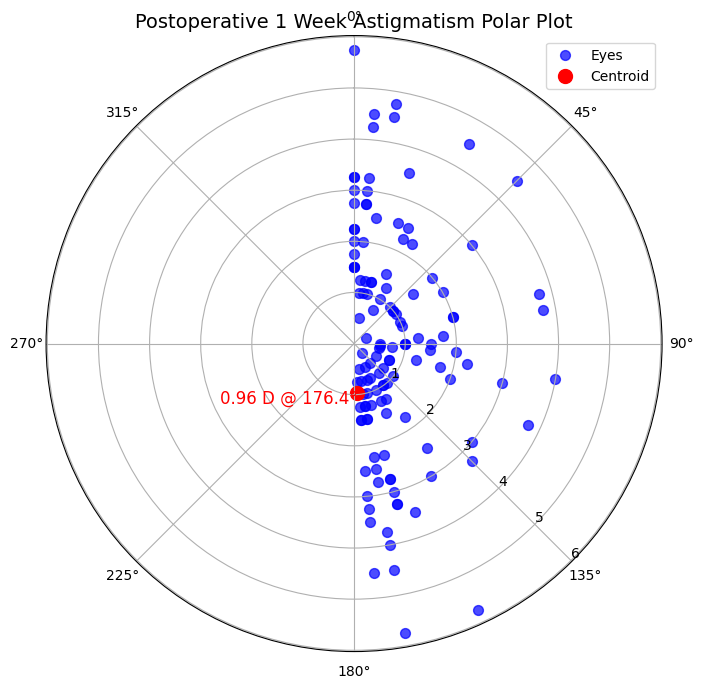

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Use minus-cylinder notation data
cyl = rawdata_filtered['Cyl1wk_minus']
axis = rawdata_filtered['SteepAxis1wk']

# Convert to radians
theta = np.deg2rad(axis)

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
ax.scatter(theta, np.abs(cyl), c='blue', alpha=0.7, s=50, label='Eyes')

# Centroid (J0/J45 method)
J0 = -cyl / 2 * np.cos(2 * theta)
J45 = -cyl / 2 * np.sin(2 * theta)
J0_centroid = J0.mean()
J45_centroid = J45.mean()
C_centroid = 2 * np.sqrt(J0_centroid**2 + J45_centroid**2)
axis_centroid = 0.5 * np.rad2deg(np.arctan2(J45_centroid, J0_centroid))
if axis_centroid < 0:
    axis_centroid += 180
ax.scatter(np.deg2rad(axis_centroid), C_centroid, c='red', s=100, label='Centroid')
ax.text(np.deg2rad(axis_centroid), C_centroid + 0.2,
        f"{C_centroid:.2f} D @ {axis_centroid:.1f}°",
        color='red', fontsize=12, ha='right')

# Formatting
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rlabel_position(135)
ax.set_title('Postoperative 1 Week Astigmatism Polar Plot', fontsize=14)
ax.legend(loc='upper right')

plt.show()


In [ ]:
# Compute preoperative vector components
preJ0 = -rawdata_filtered['PreopCylinder'] / 2 * np.cos(2 * np.deg2rad(rawdata_filtered['PreopSteepAxis']))
preJ45 = -rawdata_filtered['PreopCylinder'] / 2 * np.sin(2 * np.deg2rad(rawdata_filtered['PreopSteepAxis']))

# Postop 1wk vector components
postJ0 = -rawdata_filtered['Cyl1wk_minus'] / 2 * np.cos(2 * np.deg2rad(rawdata_filtered['SteepAxis1wk']))
postJ45 = -rawdata_filtered['Cyl1wk_minus'] / 2 * np.sin(2 * np.deg2rad(rawdata_filtered['SteepAxis1wk']))

# Change in astigmatism vector (Surgically Induced Astigmatism approximation)
rawdata_filtered['dJ0'] = postJ0 - preJ0
rawdata_filtered['dJ45'] = postJ45 - preJ45
rawdata_filtered['SIA_magnitude'] = 2 * np.sqrt(rawdata_filtered['dJ0']**2 + rawdata_filtered['dJ45']**2)
rawdata_filtered['SIA_axis'] = 0.5 * np.rad2deg(np.arctan2(rawdata_filtered['dJ45'], rawdata_filtered['dJ0']))

print(rawdata_filtered[['SIA_magnitude', 'SIA_axis']].describe())


       SIA_magnitude    SIA_axis
count     131.000000  131.000000
mean        2.333926   -3.038100
std         1.397883   43.898006
min         0.174311  -87.500000
25%         1.208039  -25.836316
50%         2.098105   -5.000000
75%         3.243026   20.001431
max         6.342881   85.000000


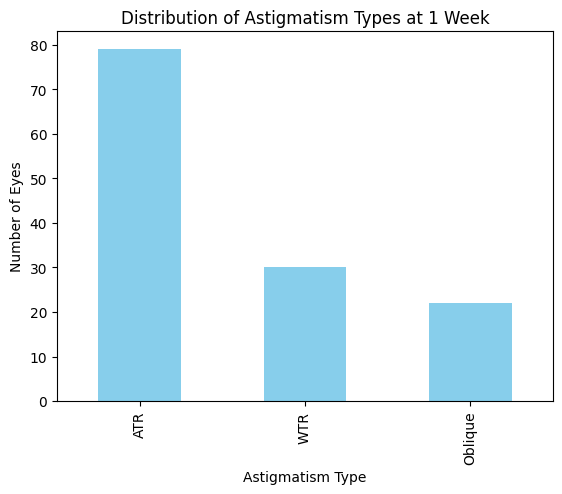

In [ ]:
# Bar plot of astigmatism type distribution
rawdata_filtered['Postop1wk_AstigType'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Distribution of Astigmatism Types at 1 Week')
plt.xlabel('Astigmatism Type')
plt.ylabel('Number of Eyes')
plt.show()


=== Descriptive Statistics (Postop 1 Week) ===
       Sph1wk_minus  Cyl1wk_minus       SE1wk
count    131.000000    131.000000  131.000000
mean       0.471374     -2.061069   -0.559160
std        1.724719      1.281185    1.748786
min       -3.250000     -5.750000   -5.500000
25%       -0.750000     -3.000000   -1.375000
50%        0.500000     -1.750000   -0.500000
75%        1.500000     -1.000000    0.500000
max        6.750000     -0.250000    5.125000

=== Astigmatism Type Distribution (Postop 1 Week) ===
ATR     : 79 eyes (45.9%)
nan     : 41 eyes (23.8%)
WTR     : 30 eyes (17.4%)
Oblique : 22 eyes (12.8%)


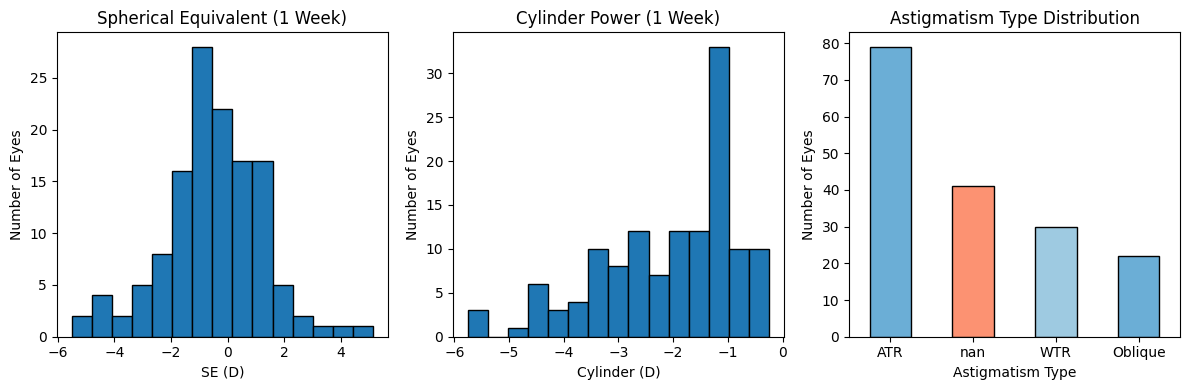

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Summary statistics for SE and Cylinder ---
desc_summary = rawdata_filtered[['Sph1wk_minus', 'Cyl1wk_minus', 'SE1wk']].describe()
print("=== Descriptive Statistics (Postop 1 Week) ===")
print(desc_summary)

# --- 2. Astigmatism type frequency distribution ---
astig_counts = rawdata_filtered['Postop1wk_AstigType'].value_counts(dropna=False)
astig_percent = 100 * astig_counts / astig_counts.sum()

print("\n=== Astigmatism Type Distribution (Postop 1 Week) ===")
# for t in astig_counts.index:
    # pct = astig_percent[t]
    # print(f"{t:8s}: {astig_counts[t]} eyes ({pct:.1f}%)")

for t in astig_counts.index:
    t_str = str(t)  # safely convert to string (handles NaN)
    pct = astig_percent[t]
    print(f"{t_str:8s}: {astig_counts[t]} eyes ({pct:.1f}%)")


# --- 3. Optional: Visual summaries ---
plt.figure(figsize=(12, 4))

# (a) Histogram of SE
plt.subplot(1, 3, 1)
plt.hist(rawdata_filtered['SE1wk'].dropna(), bins=15, edgecolor='black')
plt.title('Spherical Equivalent (1 Week)')
plt.xlabel('SE (D)')
plt.ylabel('Number of Eyes')

# (b) Histogram of Cylinder
plt.subplot(1, 3, 2)
plt.hist(rawdata_filtered['Cyl1wk_minus'].dropna(), bins=15, edgecolor='black')
plt.title('Cylinder Power (1 Week)')
plt.xlabel('Cylinder (D)')
plt.ylabel('Number of Eyes')

# (c) Bar chart of Astigmatism Type
plt.subplot(1, 3, 3)
astig_counts.plot(kind='bar', color=['#6baed6', '#fc9272', '#9ecae1'], edgecolor='black')
plt.title('Astigmatism Type Distribution')
plt.xlabel('Astigmatism Type')
plt.ylabel('Number of Eyes')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


In [50]:
import pandas as pd
import numpy as np

# --- Cross-tabulation of preop vs postop (1 week) astigmatism types ---
shift_table = pd.crosstab(
    rawdata_filtered['Preop_AstigType'],
    rawdata_filtered['Postop1wk_AstigType'],
    margins=True
)

print("=== Astigmatism Type Shift: Preop → 1 Week Postop ===")
print(shift_table)

# --- Calculate percentage version ---
shift_table_pct = shift_table.div(shift_table.loc['All'], axis=1) * 100
print("\n=== Percentage Distribution (by Postop type) ===")
print(shift_table_pct.round(1))

# --- Optional: Summary of major shifts ---
n_total = len(rawdata_filtered)
same_type = (rawdata_filtered['Preop_AstigType'] == rawdata_filtered['Postop1wk_AstigType']).sum()
changed_type = n_total - same_type

print(f"\nSame astigmatism type pre → postop: {same_type} eyes ({same_type/n_total*100:.1f}%)")
print(f"Changed astigmatism type: {changed_type} eyes ({changed_type/n_total*100:.1f}%)")


=== Astigmatism Type Shift: Preop → 1 Week Postop ===
Postop1wk_AstigType  ATR  Oblique  WTR  All
Preop_AstigType                            
ATR                   25       10   11   46
Oblique               16        4    6   26
WTR                   38        8   13   59
All                   79       22   30  131

=== Percentage Distribution (by Postop type) ===
Postop1wk_AstigType    ATR  Oblique    WTR    All
Preop_AstigType                                  
ATR                   31.6     45.5   36.7   35.1
Oblique               20.3     18.2   20.0   19.8
WTR                   48.1     36.4   43.3   45.0
All                  100.0    100.0  100.0  100.0

Same astigmatism type pre → postop: 42 eyes (24.4%)
Changed astigmatism type: 130 eyes (75.6%)
